In [2]:
"""
Example notebook code for testing TripletCreator and visualizing triplets.

Copy this into a Jupyter notebook cell to test the triplet creation.
"""

# Cell 1: Import and setup
import matplotlib.pyplot as plt
import numpy as np
import torch
import os

# move to the parent directory
os.chdir('..')

try:
    from galaxy_images.galaxy_triplets import TripletCreator
except ImportError:
    # If running from inside galaxy_images/, use relative import
    from galaxy_triplets import TripletCreator


/root/miniconda3/envs/rocm-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

# Cell 2: Create TripletCreator (using just 1 file for quick testing)
creator = TripletCreator(
    dataset_path="/mnt/scratch/legacysurvey_hsc_crossmatched/data",
    files_to_use=1,  # Use just 1 parquet file for quick testing
    seed=None
)

print(f"Dataset loaded: {creator.num_rows} rows")


Dataset loaded: 257 rows


In [5]:

# Cell 3: Create a single triplet (with object mask enabled)
triplet = creator.create_triplet(anchor_survey='hsc', use_object_mask=True)

print("Triplet created!")
print(f"Ground truth tensor shape: {triplet['ground_truth']['tensor'].shape}")
print(f"Ground truth instrument: {triplet['ground_truth']['instrument_onehot']}")
print(f"Cross instrument: {triplet['cross_instrument']['instrument_onehot']}")
print(f"Include object mask: {triplet.get('include_object_mask', False)}")


Triplet created!
Ground truth tensor shape: torch.Size([13, 160, 160])
Ground truth instrument: tensor([0., 1.])
Cross instrument: tensor([1., 0.])
Include object mask: True


In [8]:

# Cell 4: Helper function to visualize RGB from tensor
def tensor_to_rgb(tensor, channels=[0, 1, 2], percentile_clip=99.5):
    """
    Extract RGB channels from tensor and normalize for visualization.

    Args:
        tensor: Tensor of shape (C, H, W)
        channels: Which channels to use for R, G, B (default: [0,1,2] for flux channels)
        percentile_clip: Percentile to clip at for better contrast

    Returns:
        RGB array of shape (H, W, 3) in range [0, 1]
    """
    # Extract the specified channels
    rgb = tensor[channels].cpu().numpy()  # (3, H, W)

    # Transpose to (H, W, 3)
    rgb = np.transpose(rgb, (1, 2, 0))

    # Clip outliers using percentile
    for i in range(3):
        p_low = np.percentile(rgb[:, :, i], 100 - percentile_clip)
        p_high = np.percentile(rgb[:, :, i], percentile_clip)
        rgb[:, :, i] = np.clip(rgb[:, :, i], p_low, p_high)

    # Normalize each channel to [0, 1]
    for i in range(3):
        ch = rgb[:, :, i]
        ch_min, ch_max = ch.min(), ch.max()
        if ch_max > ch_min:
            rgb[:, :, i] = (ch - ch_min) / (ch_max - ch_min)
        else:
            rgb[:, :, i] = 0.0

    return rgb


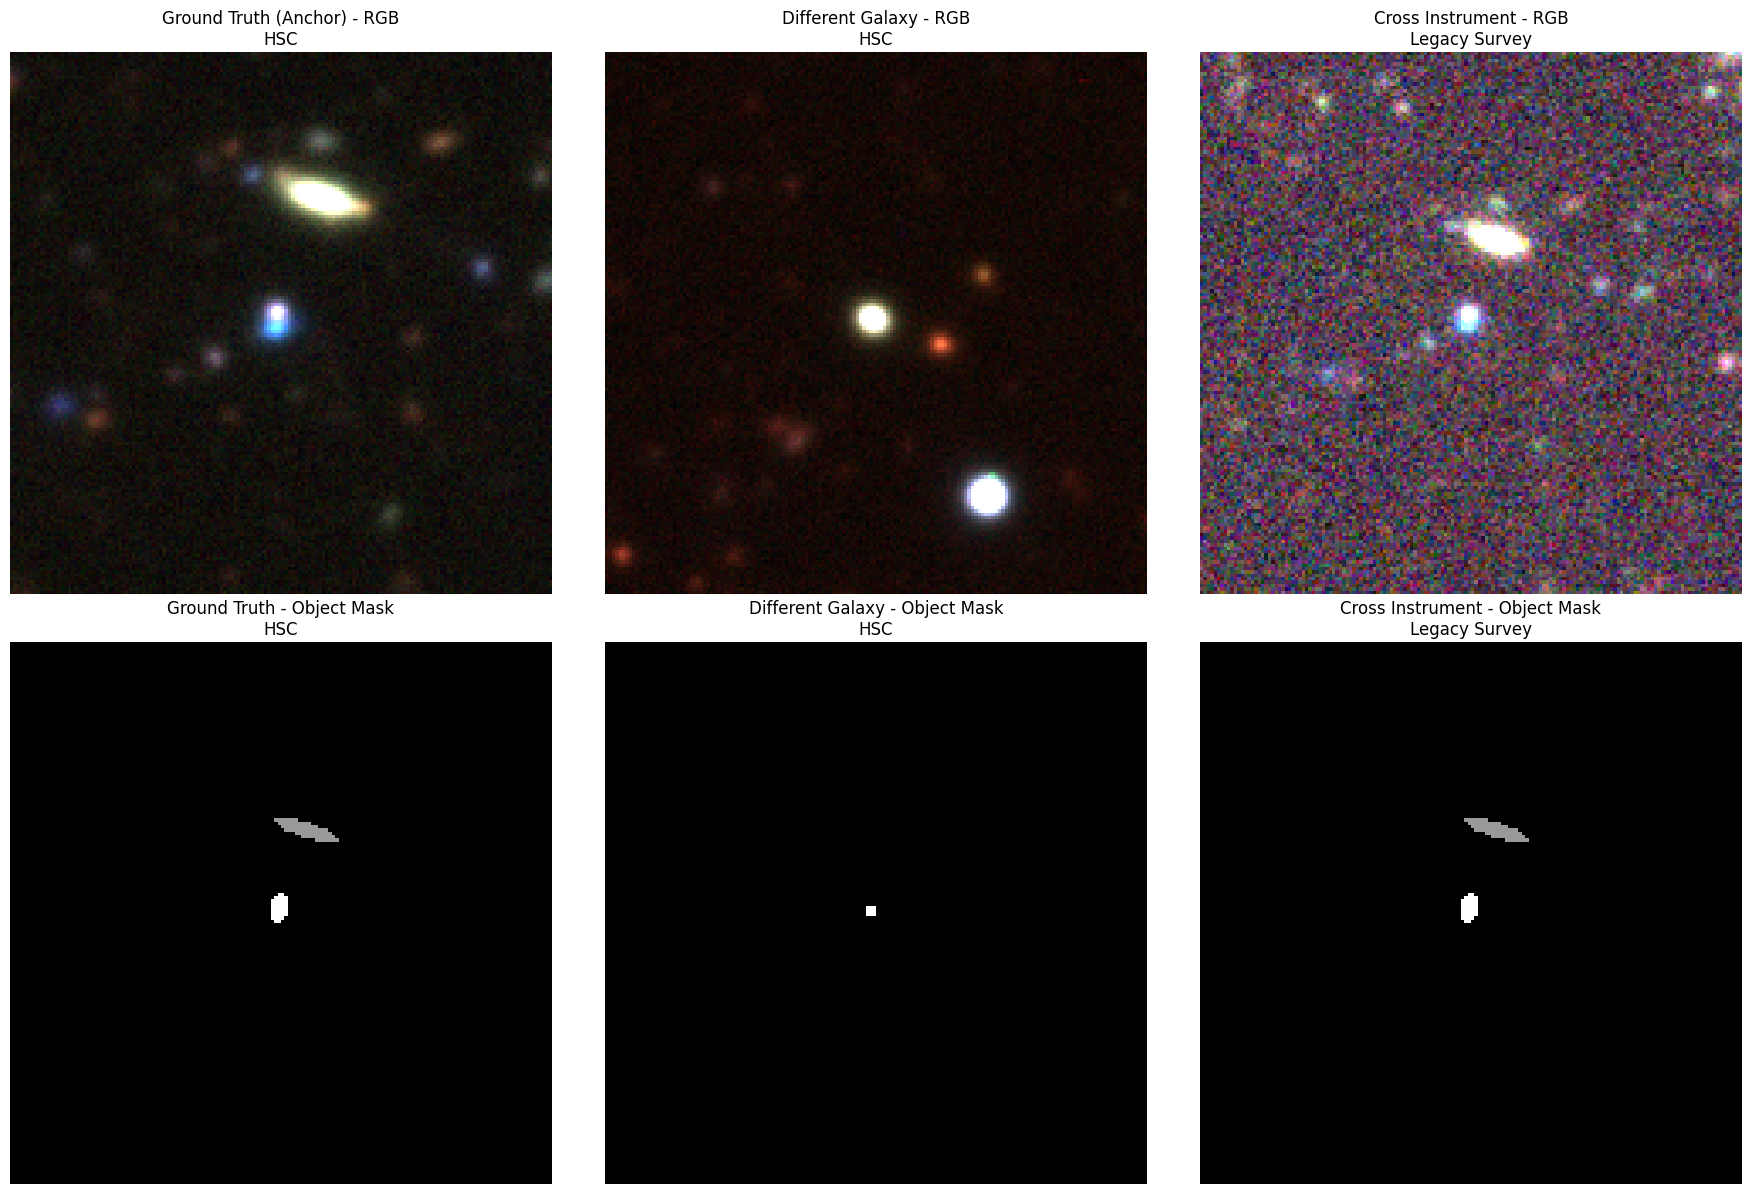


Metadata:
Anchor index: 12
Different galaxy index: 82
Include object mask: True

Ground truth PSF FWHM: tensor([0.8231, 0.8179, 0.7516, 0.7616])
Ground truth scale: 0.1679999977350235
Ground truth tensor shape: torch.Size([13, 160, 160])

Max value in gt_rgb: 1.0
Min value in gt_rgb: 0.0
Max value in diff_rgb: 1.0
Min value in diff_rgb: 0.0
Max value in cross_rgb: 1.0
Min value in cross_rgb: 0.0


In [ ]:

# Cell 5: Visualize the triplet - RGB (flux) and Object Mask
# Create 2 rows x 3 columns: Row 1 = RGB (flux), Row 2 = Object Mask
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Helper to get instrument name
def get_instrument_name(instrument_onehot):
    return 'Legacy Survey' if instrument_onehot[0] > 0.5 else 'HSC'

# Helper to extract and normalize single channel for visualization
def tensor_to_single_channel(tensor, channel_idx):
    """
    Extract a single channel from tensor and normalize for visualization.

    Args:
        tensor: Tensor of shape (C, H, W)
        channel_idx: Index of channel to extract

    Returns:
        Grayscale array of shape (H, W) in range [0, 1]
    """
    if channel_idx >= tensor.shape[0]:
        return None

    channel = tensor[channel_idx].cpu().numpy()  # (H, W)

    # Normalize to [0, 1]
    ch_min, ch_max = channel.min(), channel.max()
    if ch_max > ch_min:
        channel = (channel - ch_min) / (ch_max - ch_min)
    else:
        channel = np.zeros_like(channel)

    return channel

# Ground truth (anchor image)
gt_tensor = triplet['ground_truth']['tensor']
gt_scale = triplet['ground_truth']['scale'].cpu().numpy()
gt_fwhm = triplet['ground_truth']['psf_fwhm'].cpu().numpy()
gt_instrument = triplet['ground_truth']['instrument_onehot']
gt_instrument_name = get_instrument_name(gt_instrument)

# RGB from flux channels (0, 1, 2)
gt_rgb = tensor_to_rgb(gt_tensor, channels=[0, 1, 2])
axes[0, 0].imshow(gt_rgb, vmin=0, vmax=1)
axes[0, 0].set_title(f'Ground Truth (Anchor) - RGB\n{gt_instrument_name}', fontsize=12)
axes[0, 0].axis('off')

# Object mask (channel 12)
gt_object_mask = tensor_to_single_channel(gt_tensor, channel_idx=12)
if gt_object_mask is not None:
    axes[1, 0].imshow(gt_object_mask, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title(f'Ground Truth - Object Mask\n{gt_instrument_name}', fontsize=12)
else:
    axes[1, 0].text(0.5, 0.5, 'Object mask not available\n(use_object_mask=False)',
                     ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title(f'Ground Truth - Object Mask\n{gt_instrument_name}', fontsize=12)
axes[1, 0].axis('off')

# Different galaxy (same instrument)
diff_tensor = triplet['different_galaxy']['tensor']
diff_instrument = triplet['different_galaxy']['instrument_onehot']
diff_instrument_name = get_instrument_name(diff_instrument)

# RGB from flux channels
diff_rgb = tensor_to_rgb(diff_tensor, channels=[0, 1, 2])
axes[0, 1].imshow(diff_rgb, vmin=0, vmax=1)
axes[0, 1].set_title(f'Different Galaxy - RGB\n{diff_instrument_name}', fontsize=12)
axes[0, 1].axis('off')

# Object mask (channel 12)
diff_object_mask = tensor_to_single_channel(diff_tensor, channel_idx=12)
if diff_object_mask is not None:
    axes[1, 1].imshow(diff_object_mask, cmap='gray', vmin=0, vmax=1)
    axes[1, 1].set_title(f'Different Galaxy - Object Mask\n{diff_instrument_name}', fontsize=12)
else:
    axes[1, 1].text(0.5, 0.5, 'Object mask not available\n(use_object_mask=False)',
                     ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title(f'Different Galaxy - Object Mask\n{diff_instrument_name}', fontsize=12)
axes[1, 1].axis('off')

# Cross instrument (same galaxy, different instrument)
cross_tensor = triplet['cross_instrument']['tensor']
cross_instrument = triplet['cross_instrument']['instrument_onehot']
cross_instrument_name = get_instrument_name(cross_instrument)

# RGB from flux channels
cross_rgb = tensor_to_rgb(cross_tensor, channels=[0, 1, 2])
axes[0, 2].imshow(cross_rgb, vmin=0, vmax=1)
axes[0, 2].set_title(f'Cross Instrument - RGB\n{cross_instrument_name}', fontsize=12)
axes[0, 2].axis('off')

# Object mask (channel 12)
cross_object_mask = tensor_to_single_channel(cross_tensor, channel_idx=12)
if cross_object_mask is not None:
    axes[1, 2].imshow(cross_object_mask, cmap='gray', vmin=0, vmax=1)
    axes[1, 2].set_title(f'Cross Instrument - Object Mask\n{cross_instrument_name}', fontsize=12)
else:
    axes[1, 2].text(0.5, 0.5, 'Object mask not available\n(use_object_mask=False)',
                     ha='center', va='center', transform=axes[1, 2].transAxes)
    axes[1, 2].set_title(f'Cross Instrument - Object Mask\n{cross_instrument_name}', fontsize=12)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Cell 6: Print some metadata
print("\nMetadata:")
print(f"Anchor index: {triplet['anchor_index']}")
print(f"Different galaxy index: {triplet['different_index']}")
print(f"Include object mask: {triplet.get('include_object_mask', 'N/A')}")
print(f"\nGround truth PSF FWHM: {triplet['ground_truth']['psf_fwhm']}")
print(f"Ground truth scale: {triplet['ground_truth']['scale']}")
print(f"Ground truth tensor shape: {triplet['ground_truth']['tensor'].shape}")

print(f'\nMax value in gt_rgb: {gt_rgb.max()}')
print(f'Min value in gt_rgb: {gt_rgb.min()}')

print(f'Max value in diff_rgb: {diff_rgb.max()}')
print(f'Min value in diff_rgb: {diff_rgb.min()}')

print(f'Max value in cross_rgb: {cross_rgb.max()}')
print(f'Min value in cross_rgb: {cross_rgb.min()}')
